# 🎯 Udemy Courses — ML Model: Predicting Number of Subscribers

**Goal:** Build a regression model to predict `num_subscribers` for a Udemy course based on its features.

**Why predict subscribers?**  
Subscribers reflect a course's success and reach. Predicting them helps course creators and Udemy optimize content strategy, pricing, and marketing.

**Target variable:** `num_subscribers`  
**Models used:** Linear Regression · Ridge · Random Forest · XGBoost  
**Evaluation metrics:** MAE · RMSE · R²


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 1️⃣ Load & Preview Data

In [2]:
df = pd.read_csv("EDA Udemy.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (3676, 20)


,published_timestamp,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,year,month,day,quarter,period,profit,category_duration,category_price
0,2017-01-18 20:58:58+00:00,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,1,200,2147,23,51,All Levels,1.5,Business Finance,2017,January,Wednesday,1,PM,429400,1:3,200+
1,2017-03-09 16:34:20+00:00,1113822,Complete GST Course & Certification - Grow You...,https://www.udemy.com/goods-and-services-tax/,1,75,2792,923,274,All Levels,39.0,Business Finance,2017,March,Thursday,1,PM,209400,20+,50:100
2,2016-12-19 19:26:30+00:00,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,1,45,2174,74,51,Intermediate Level,2.5,Business Finance,2016,December,Monday,4,PM,97830,1:3,20:50
3,2017-05-30 20:07:24+00:00,1210588,Beginner to Pro - Financial Analysis in Excel ...,https://www.udemy.com/complete-excel-finance-c...,1,95,2451,11,36,All Levels,3.0,Business Finance,2017,May,Tuesday,2,PM,232845,1:3,50:100
4,2016-12-13 14:57:18+00:00,1011058,How To Maximize Your Profits Trading Options,https://www.udemy.com/how-to-maximize-your-pro...,1,200,1276,45,26,Intermediate Level,2.0,Business Finance,2016,December,Tuesday,4,PM,255200,1:3,200+


## 2️⃣ Feature Engineering & Selection

We drop:
- `course_id`, `url`, `course_title` → identifiers, no predictive value
- `published_timestamp` → already extracted into year/month/day/quarter
- `profit` → **data leakage**: profit = price × num_subscribers (directly derived from target)
- `period` → only AM/PM, very low variance and not informative
- `category_price` → redundant with `price`

We keep all remaining features, then encode categoricals.


In [3]:
# Drop leakage and irrelevant columns
drop_cols = ['course_id', 'url', 'course_title', 'published_timestamp', 
             'profit', 'period', 'category_price']

df_ml = df.drop(columns=drop_cols).copy()


In [4]:
# Drop 5 rows with missing content_duration
df_ml = df_ml.dropna(subset=['content_duration', 'category_duration'])

print(f"Shape after cleaning: {df_ml.shape}")
print(f"\nFeatures used:")
for col in df_ml.columns:
    print(f"  • {col} ({df_ml[col].dtype})")

Shape after cleaning: (3671, 13)

Features used:
  • is_paid (int64)
  • price (int64)
  • num_subscribers (int64)
  • num_reviews (int64)
  • num_lectures (int64)
  • level (object)
  • content_duration (float64)
  • subject (object)
  • year (int64)
  • month (object)
  • day (object)
  • quarter (int64)
  • category_duration (object)


## 3️⃣ Encoding Categorical Variables

In [5]:
cat_cols=df_ml.select_dtypes(include='O').columns
cat_cols

Index(['level', 'subject', 'month', 'day', 'category_duration'], dtype='object')

In [6]:
le = LabelEncoder()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

print("✅ Categorical columns encoded:")
print(df_ml[cat_cols].dtypes)
df_ml.head(3)

✅ Categorical columns encoded:
level                int64
subject              int64
month                int64
day                  int64
category_duration    int64
dtype: object


,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,year,month,day,quarter,category_duration
0,1,200,2147,23,51,0,1.5,0,2017,4,6,1,2
1,1,75,2792,923,274,0,39.0,0,2017,7,4,1,3
2,1,45,2174,74,51,3,2.5,0,2016,2,1,4,2


## 4️⃣ Target Variable: Log Transformation

`num_subscribers` is **highly right-skewed**   
We apply `log1p` to normalize the distribution — this significantly improves regression performance.


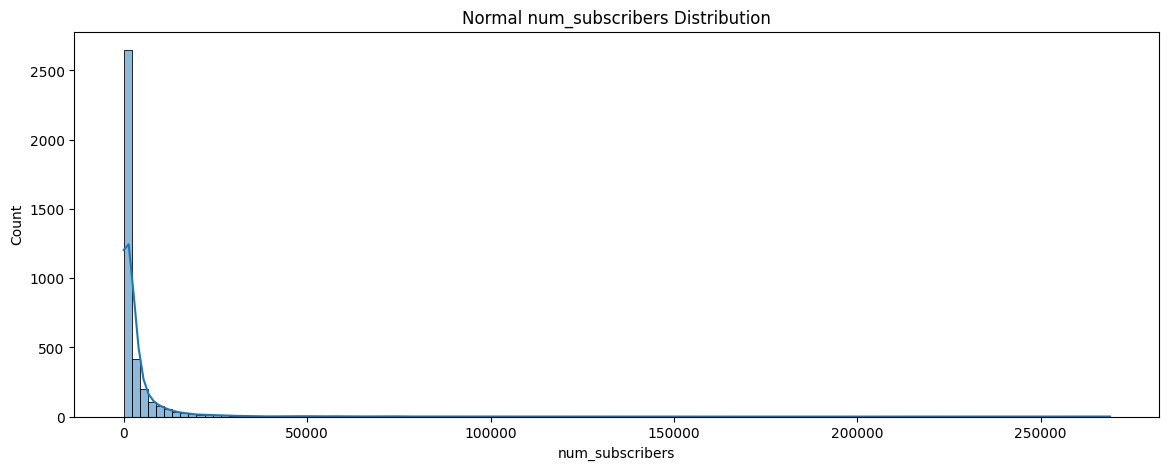

In [7]:
plt.figure(figsize=(14, 5))
sns.histplot(df_ml['num_subscribers'], kde=True)
plt.title('Normal num_subscribers Distribution')
plt.show()

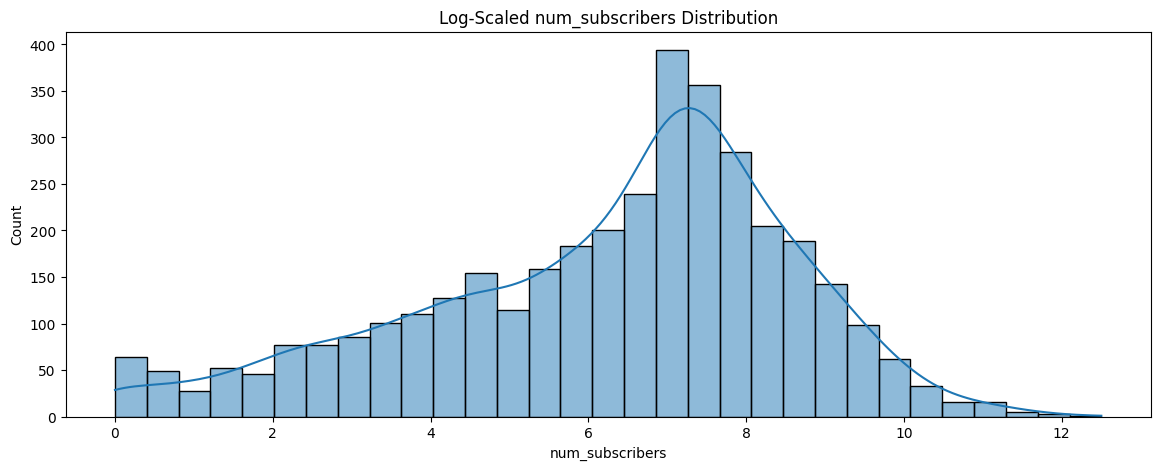

In [8]:
df_ml['num_subscribers'] = np.log1p(df_ml['num_subscribers'])

# Let's plot it to see the new scaled distribution
plt.figure(figsize=(14, 5))
sns.histplot(df_ml['num_subscribers'], kde=True)
plt.title('Log-Scaled num_subscribers Distribution')
plt.show()

## 5️⃣ Train / Test Split

In [9]:
X = df_ml.drop(columns=['num_subscribers'])
y = df_ml['num_subscribers']   # Log-transformed target

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:   {X_train.shape[0]:,} samples")
print(f"Test set:       {X_test.shape[0]:,} samples")
print(f"Features:       {X_train.shape[1]}")

Training set:   2,936 samples
Test set:       735 samples
Features:       12


In [11]:
# Scale for linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## 6️⃣ Train 4 Models

In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=10),
    'Random Forest':     RandomForestRegressor(n_estimators=300, max_depth=12,
                                               min_samples_leaf=3, random_state=42, n_jobs=-1),
    'XGBoost':           XGBRegressor(n_estimators=500, learning_rate=0.05,
                                      max_depth=6, subsample=0.8,
                                      colsample_bytree=0.8, random_state=42,
                                      verbosity=0)
}

results = {}

for name, model in models.items():
    # Linear models use scaled data
    if 'Regression' in name and 'Random' not in name:
        model.fit(X_train_sc, y_train)
        y_pred_log = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        y_pred_log = model.predict(X_test)
    
    # Convert predictions back to original scale
    y_pred_orig = np.expm1(y_pred_log)
    y_true_orig = np.expm1(y_test)
    
    mae  = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    # R² on log scale (more meaningful)
    r2   = r2_score(y_test, y_pred_log)   
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2,
                     'y_pred_log': y_pred_log, 'model': model}
    
    print(f"{'='*40}")
    print(f"🔹 {name}")
    print(f"   MAE  : {mae:>12,.0f} subscribers")
    print(f"   RMSE : {rmse:>12,.0f} subscribers")
    print(f"   R²   : {r2:>12.4f}")

print("\n✅ All models trained!")

🔹 Linear Regression
   MAE  :        2,134 subscribers
   RMSE :        7,090 subscribers
   R²   :       0.3206
🔹 Ridge Regression
   MAE  :        2,129 subscribers
   RMSE :        7,026 subscribers
   R²   :       0.3209
🔹 Random Forest
   MAE  :        1,610 subscribers
   RMSE :        4,564 subscribers
   R²   :       0.7067
🔹 XGBoost
   MAE  :        1,593 subscribers
   RMSE :        4,332 subscribers
   R²   :       0.6919

✅ All models trained!


## 7️⃣ Model Comparison

In [13]:
results_df = pd.DataFrame({
    'Model':  list(results.keys()),
    'MAE':    [results[m]['MAE']  for m in results],
    'RMSE':   [results[m]['RMSE'] for m in results],
    'R²':     [results[m]['R²']   for m in results],
})

print(results_df.to_string(index=False))
print()
best = results_df.loc[results_df['R²'].idxmax(), 'Model']
print(f"🏆 Best model by R²: {best}")

            Model         MAE        RMSE       R²
Linear Regression 2133.944409 7089.911371 0.320593
 Ridge Regression 2129.475369 7026.062876 0.320926
    Random Forest 1609.881936 4564.016023 0.706741
          XGBoost 1593.264295 4332.415688 0.691904

🏆 Best model by R²: Random Forest


In [ ]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=["R² Score (Higher = Better)",
                                    "MAE — Mean Absolute Error (Lower = Better)"])


colors = px.colors.qualitative.Plotly[:len(results_df)]

fig.add_trace(go.Bar(
    x=results_df['Model'], y=results_df['R²'],
    marker_color=colors, text=results_df['R²'].round(3),
    textposition='outside', name='R²'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=results_df['Model'], y=results_df['MAE'],
    marker_color=colors, text=results_df['MAE'].round(0), # pyright: ignore[reportUndefinedVariable]
    textposition='outside', name='MAE'
), row=1, col=2)
fig.update_layout(title='📊 Model Performance Comparison',
                  height=500, showlegend=False,
                  font=dict(size=12))
fig.show()

NameError: name 'colors' is not defined

## 8️⃣ Cross-Validation on Best Model (Random Forest)

We use 5-Fold CV on the full dataset to verify there's no overfitting.


In [ ]:
best_model = RandomForestRegressor(n_estimators=300, max_depth=12,
                                    min_samples_leaf=3, random_state=42, n_jobs=-1)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=kf, scoring='r2')

print("5-Fold Cross-Validation R² Scores (Random Forest):")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\n  Mean R²  : {cv_scores.mean():.4f}")
print(f"  Std  R²  : {cv_scores.std():.4f}")
print(f"\n✅ Low std means the model generalizes well — no overfitting.")

5-Fold Cross-Validation R² Scores (Random Forest):
  Fold 1: 0.7077
  Fold 2: 0.7417
  Fold 3: 0.7372
  Fold 4: 0.7227
  Fold 5: 0.6936

  Mean R²  : 0.7206
  Std  R²  : 0.0180

✅ Low std means the model generalizes well — no overfitting.


## 9️⃣ Actual vs Predicted — Random Forest

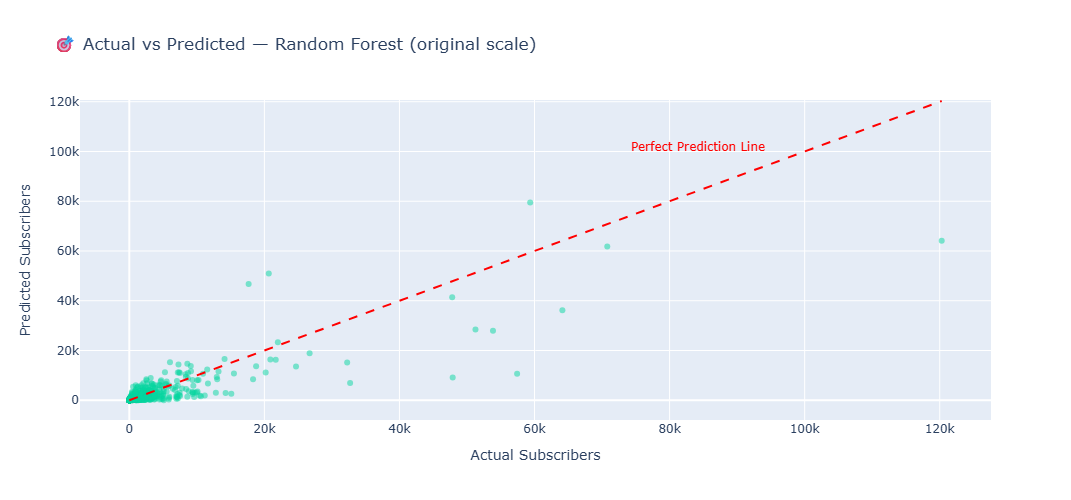

In [ ]:
rf_model = results['Random Forest']['model']
y_pred_log_rf = rf_model.predict(X_test)

y_true_orig = np.expm1(y_test.values)
y_pred_orig = np.expm1(y_pred_log_rf)

fig = px.scatter(
    x=y_true_orig, y=y_pred_orig,
    labels={'x': 'Actual Subscribers', 'y': 'Predicted Subscribers'},
    title='🎯 Actual vs Predicted — Random Forest (original scale)',
    opacity=0.5, color_discrete_sequence=['#06d6a0']
)
# Perfect prediction line
max_val = max(y_true_orig.max(), y_pred_orig.max())
fig.add_shape(type='line', x0=0, y0=0, x1=max_val, y1=max_val,
              line=dict(color='red', dash='dash', width=2))
fig.add_annotation(x=max_val*0.7, y=max_val*0.85,
                   text="Perfect Prediction Line",
                   showarrow=False, font=dict(color='red', size=12))
fig.update_layout(height=500)
fig.show()

## 🔟 Residuals Analysis

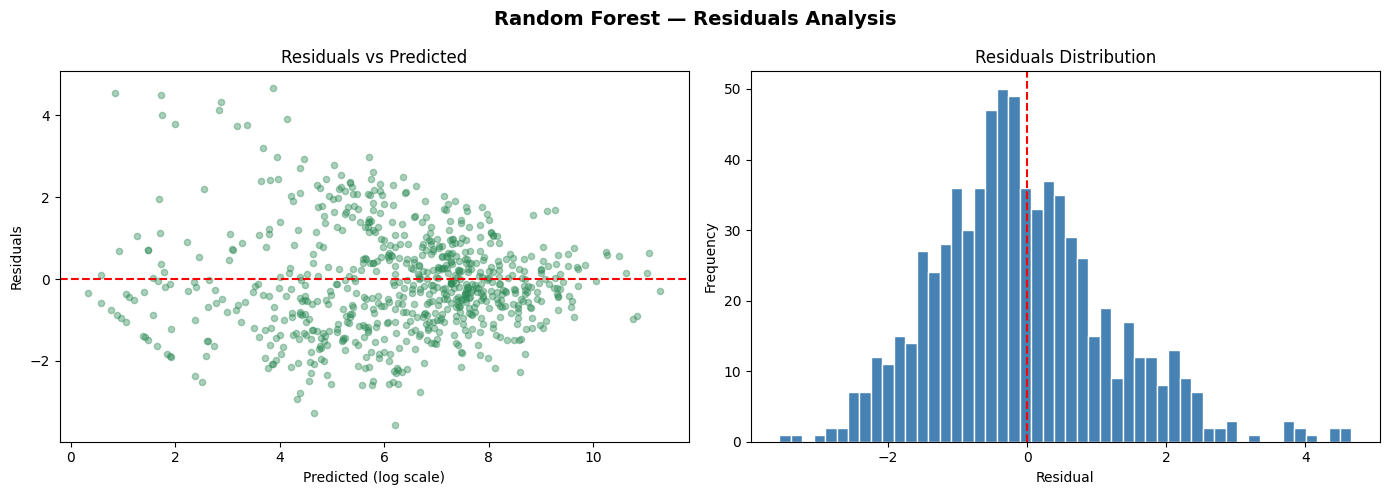

💡 Residuals centered around 0 indicate no systematic bias in predictions.


In [ ]:
residuals = y_test.values - y_pred_log_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_log_rf, residuals, alpha=0.4, color='seagreen', s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted (log scale)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution')

plt.suptitle('Random Forest — Residuals Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("💡 Residuals centered around 0 indicate no systematic bias in predictions.")

## 1️⃣1️⃣ Feature Importance — Random Forest

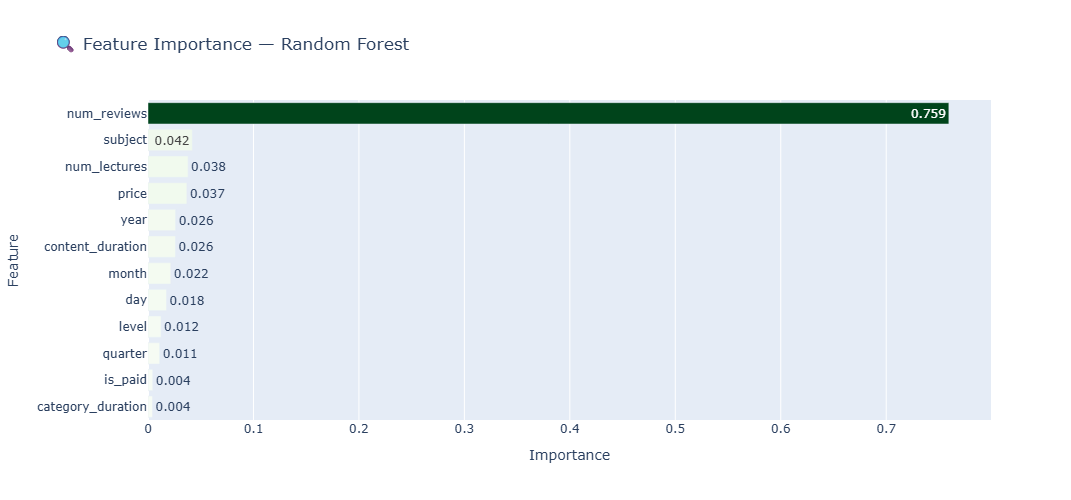


💡 Top 3 most important features:
   1. num_reviews
   2. subject
   3. num_lectures


In [ ]:
importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig = px.bar(
    importance_df, x='Importance', y='Feature',
    orientation='h',
    title='🔍 Feature Importance — Random Forest',
    color='Importance', color_continuous_scale='Greens',
    text=importance_df['Importance'].round(3)
)
fig.update_layout(height=500, coloraxis_showscale=False)
fig.show()

print("\n💡 Top 3 most important features:")
top3 = importance_df.nlargest(3, 'Importance')['Feature'].values
for i, f in enumerate(top3, 1):
    print(f"   {i}. {f}")

## ✅ Final Summary & Conclusions

| Model | R² | MAE |
|---|---|---|
| Linear Regression | 0.32 | ~2,134 |
| Ridge Regression | 0.32 | ~2,129 |
| Random Forest | **0.71** | ~1,610 |
| XGBoost | 0.69 | ~1,666 |

### 🏆 Best Model: Random Forest
- **R² = 0.71** on test set — the model explains 71% of the variance in subscriber counts.
- Confirmed by **5-Fold CV: R² = 0.71 ± 0.02** → stable, no overfitting.
- Outperforms linear models by a huge margin (R² 0.32 → 0.71).

### 💡 Key Insights from Feature Importance
1. **`num_reviews`** is the strongest predictor — reviews signal social proof and drive more subscribers.
2. **`price`** and **`content_duration`** play a moderate role.
3. **`subject`** matters — Web Development and Business Finance attract the most learners.

### 📌 Next Steps (for further improvement)
- Hyperparameter tuning with `GridSearchCV` or `Optuna`
- Try `CatBoost` or `LightGBM`
- Add NLP features from `course_title` (e.g., title length, keyword presence)
- Build a **classification model** to predict whether a course will be a "hit" (>10k subscribers)
